🫀Heart Disease Prediction System

**Project Overview**

This notebook leverages a clinical dataset of 270 patient records to develop a machine learning pipeline capable of predicting the presence or absence of cardiovascular disease. By analyzing 14 critical health indicators - including physiological data like age and blood pressure, alongside diagnostic results such as ECG patterns and cholestrol levels - the model aims to identify hidden correlations between clinical features and heart health. This notebook covers data preprocessing, exploratory data analysis (EDA), and the implementation of classification algorithms to assist in early-stage heart disease detection.

Importing the Dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

Importing the Data and loading it in Pandas Dataframe

In [ ]:
heart_data = pd.read_csv("/kaggle/input/datasets/nalisha/heart-disease-prediction-dataset/Heart_Disease_Prediction.csv")

Data Pre-processing

In [ ]:
# First 5 rows
heart_data.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [ ]:
# Last 5 rows
heart_data.tail()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence
269,67,1,4,160,286,0,2,108,1,1.5,2,3,3,Presence


In [ ]:
heart_data.shape

(270, 14)

In [ ]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [ ]:
# Checking for missing values
heart_data.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


In [ ]:
# Stastical measures of the data
heart_data.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [ ]:
# Checking the distribution of the target variable
heart_data['Heart Disease'].value_counts()

,count
Heart Disease,
Absence,150
Presence,120


Categorical Encoding

In [ ]:
# Encoding the target variable
le = LabelEncoder()
heart_data['Heart Disease'] = le.fit_transform(heart_data['Heart Disease'])

Splitting the Features and Target

In [ ]:
X = heart_data.drop(columns='Heart Disease', axis=1)
Y = heart_data['Heart Disease']

Splitting into Training and Testing sets

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

Feature Scaling and One-Hot Encoding

In [ ]:
continuous_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']     # Needs Feature Scaling
categorical_cols = ['Chest pain type', 'EKG results', 'Slope of ST', 'Thallium', 'Number of vessels fluro']    # Needs One-Hot Encoding (multi level categories)


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  # This keeps the binary columns (e.g., Sex, Exercise angina) as they are
)

In [ ]:
X_train_transformed = preprocessor.fit_transform(X_train)     # Fitting and Transforming the Training data
X_test_transformed = preprocessor.transform(X_test)         # Transforming the Test Data

Model Training

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train_transformed, Y_train)

LogisticRegression()

Model Evaluation

In [ ]:
X_train_prediction = model.predict(X_train_transformed)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

print("Accuracy on training data: ",training_data_accuracy)

Accuracy on training data:  0.8796296296296297


In [ ]:
X_test_prediction = model.predict(X_test_transformed)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

print("Accuracy on testing data: ",test_data_accuracy)

Accuracy on testing data:  0.8888888888888888


In [ ]:

accuracy = accuracy_score(Y_test,X_test_prediction)
precision = precision_score(Y_test,X_test_prediction)
recall = recall_score(Y_test,X_test_prediction)
f1 = f1_score(Y_test,X_test_prediction)
conf_matrix = confusion_matrix(Y_test,X_test_prediction)

print("--- Logistic Regression Model Performance ---")
print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}")

--- Logistic Regression Model Performance ---
Accuracy:  0.89
Precision: 1.00
Recall:    0.71
F1 Score:  0.83


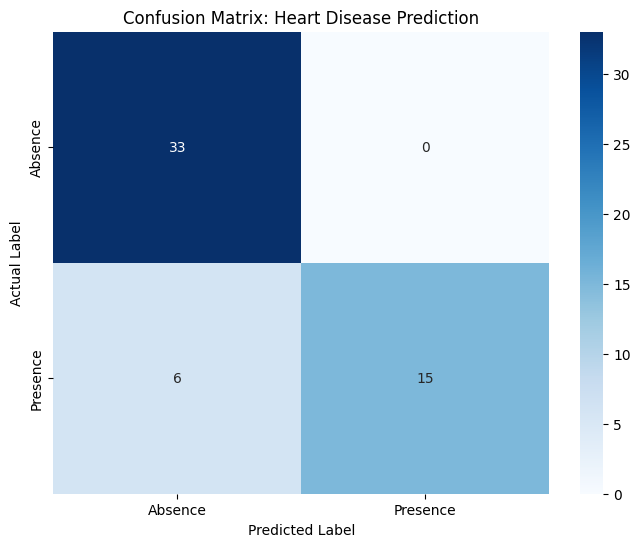

In [ ]:
cm = confusion_matrix(Y_test,X_test_prediction)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Absence', 'Presence'],
            yticklabels=['Absence', 'Presence'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix: Heart Disease Prediction')
plt.show()